In [ ]:
import pathlib

In [ ]:
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.dataset as ds
import requests
from scipy import stats as sps
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-08-29T19:24:57.606232+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1064-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

pandas    : 2.2.3
requests  : 2.34.2
teeplot   : 1.4.2
matplotlib: 3.10.7
numpy     : 2.1.2
seaborn   : 0.13.2
marimo    : 0.23.2
scipy     : 1.14.1
pyarrow   : 16.1.0

```

## Data

Load the per-replicate Hamming-weight **end-state** table produced
by the 4-site mutation-rate sweep slurm job
(`slurm/2026-08-26/2026-08-26-4site-mutation-sweep.sh`, driven by
notebook `bindle/2026-05-20-founder.py`), cached as a parquet on
OSF (https://osf.io/96r2v). The sweep targets `N_SITES=4` across a
12-condition geometric grid of `MUTATION_RATE` from `1e-5` down to
`3e-11` (~2 points per decade) at 25 replicates per condition (300
replicates planned), 150,000 steps per replicate,
POP_SIZE=1,000,000, on CPU (engine=numpy).

This sweep was still in flight when this notebook was written: not
every planned condition has completed replicates yet, and
completed conditions can have far fewer than 25 replicates apiece
--- see the `mutation_rate x replicate counts` diagnostic printed
below for the live picture, and treat the resulting confidence
intervals as provisional (they should tighten, and any missing
conditions fill in, as the sweep continues and this OSF file is
refreshed).

Unlike the smaller companion sweeps, the OSF file backing this
notebook is the **full per-step trajectory table** (one row per
`(replicate_uid, Step, hw)`) rather than a pre-filtered end-state
export, so loading it wholesale with `pandas` risks exhausting
memory. Instead, the final-step filter (`Step == max(Step)`) is
pushed down through `pyarrow.dataset` before materializing to
`pandas`, since every completed replicate is recorded densely for
every step (no checkpointing).

The OSF file is downloaded with `requests` and cached at
`/tmp/<slug>` so re-runs hit the local copy.

In [ ]:
# CLI args. Defaults pull the 4-site mutation-sweep hw parquet that
# backs this notebook (OSF https://osf.io/96r2v).
_args = mo.cli_args()
OSF_SLUG = str(_args.get("osf-slug") or "96r2v")
OSF_URL = str(
    _args.get("osf-url") or f"https://osf.io/{OSF_SLUG}/download",
)
print(f"args: OSF_SLUG={OSF_SLUG} OSF_URL={OSF_URL}")

args: OSF_SLUG=96r2v OSF_URL=https://osf.io/96r2v/download


In [ ]:
cache_path = pathlib.Path("/tmp") / OSF_SLUG
if not cache_path.exists():
    print(f"downloading {OSF_URL} -> {cache_path}")
    resp = requests.get(OSF_URL, allow_redirects=True, timeout=300)
    resp.raise_for_status()
    cache_path.write_bytes(resp.content)
else:
    print(f"reusing cached {cache_path}")
print(f"size: {cache_path.stat().st_size} bytes")

downloading https://osf.io/96r2v/download -> /tmp/96r2v
size: 249699504 bytes


In [ ]:
# The parquet is the full per-step trajectory table (~75M rows for
# this sweep), so avoid pd.read_parquet(cache_path) --- loading
# every step of every replicate into pandas is enough on its own to
# exhaust memory on a typical runner. Every completed replicate is
# recorded densely for every step (no checkpointing), so pushing a
# Step == max(Step) filter down through pyarrow before converting
# to pandas recovers exactly the end-state rows at a fraction of
# the memory cost.
_dataset = ds.dataset(cache_path, format="parquet")
_max_step = pc.max(_dataset.to_table(columns=["Step"])["Step"]).as_py()
hw_df = _dataset.to_table(
    filter=(pc.field("Step") == _max_step),
    columns=[
        "hw",
        "n_cases",
        "replicate_uid",
        "mutation_rate",
        "n_sites",
    ],
).to_pandas()
print(f"loaded hw end-state dataframe: {hw_df.shape}")
print(
    "mutation_rate x replicate counts:\n"
    + str(hw_df.groupby("mutation_rate")["replicate_uid"].nunique()),
)

loaded hw end-state dataframe: (500, 5)
mutation_rate x replicate counts:
mutation_rate
3.000000e-11    11
1.000000e-10    10
3.000000e-10    13
1.000000e-09    10
3.000000e-09    12
1.000000e-08     4
1.000000e-07     4
3.000000e-07    20
1.000000e-06    16
Name: replicate_uid, dtype: int64


## Fixation Outcome per Replicate

For each replicate, identify the **dominant Hamming-weight class**
at its final simulation step by case count (`n_cases`) --- the
Hamming-weight bin that has "fixed" as the most-populous strain
cluster at end-state, following the coarse strain identifier used
in the founder-convergence analyses.

With `N_SITES=4` there are five Hamming-weight classes drawn from
the sixteen possible genomes:

- **founder strain (0000/1111)**: Hamming weights `0` and `4`,
  i.e. the all-zero founder/wildtype genome and its bitwise
  complement (`hw in {0, 4}`, 2 of the 16 genomes).
- **HW 1/3 complements**: Hamming weights `1` and `3`, the one-
  and three-mutation classes that are bitwise complements of one
  another (`hw in {1, 3}`, 8 of the 16 genomes).
- **HW 2 self-complementary**: Hamming weight `2`, the
  two-mutation class that is its own bitwise complement (`hw == 2`,
  the remaining 6 of the 16 genomes).

We classify each replicate's end-state into one of these three
categories, then ask how the **fixation probability of each
class** depends on the swept `mutation_rate`. Splitting HW 1/3 from
HW 2 (rather than lumping all of `hw in {1, 2, 3}` together, as the
2-/3-site companion notebooks do) matters here because the two
classes carry different genome counts (8 vs. 6 of 16) and thus
different chance baselines.

In [ ]:
_n_sites = int(hw_df["n_sites"].iloc[0])

# hw_df already holds one row per (replicate_uid, hw) at each
# replicate's final step (filtered upstream in load_data), so the
# dominant Hamming-weight class per replicate is just the hw with
# the largest n_cases.
_dom_idx = hw_df.groupby("replicate_uid")["n_cases"].idxmax()
outcome_df = hw_df.loc[
    _dom_idx,
    ["replicate_uid", "mutation_rate", "hw"],
].copy()

# Founder strain (0000/1111) == extreme Hamming weights {0, N_SITES};
# HW 2 == the self-complementary middle weight (N_SITES / 2); the
# remaining weights are the HW 1/3 complement pair.
outcome_df["group"] = outcome_df["hw"].map(
    lambda _hw: "founder (0000/1111)"
    if _hw in (0, _n_sites)
    else "HW 2 (self-complementary)"
    if _hw == _n_sites // 2
    else "HW 1/3 (complements)",
)
print(f"outcome frame: {outcome_df.shape}")
print(
    "dominant hw class counts:\n"
    + str(outcome_df["hw"].value_counts().sort_index()),
)
print(
    "group counts:\n" + str(outcome_df["group"].value_counts()),
)

outcome frame: (100, 4)
dominant hw class counts:
hw
0    12
1    23
2    42
3    18
4     5
Name: count, dtype: int64
group counts:
group
HW 2 (self-complementary)    42
HW 1/3 (complements)         41
founder (0000/1111)          17
Name: count, dtype: int64


## Exact (Clopper-Pearson) 95% Confidence Intervals

Each replicate's dominant-class label is one of three mutually
exclusive, collectively exhaustive outcomes, so for each
`mutation_rate` the "class X fixes vs. it doesn't" indicator is a
Bernoulli trial per replicate and the per-condition fraction is a
**binomial proportion**. We summarize each of the three group
proportions independently with the **exact Clopper-Pearson
interval** via `scipy.stats.binomtest(k, n).proportion_ci(
method="exact")` --- an exact estimator CI inverted from the
binomial CDF, **not** a bootstrap.
Per-condition replicate counts in this sweep snapshot are uneven
and can be as low as single digits (vs. the planned 25), so expect
some of these intervals --- especially at the sparser conditions
--- to be wide.

In [ ]:
_groups = [
    "founder (0000/1111)",
    "HW 1/3 (complements)",
    "HW 2 (self-complementary)",
]
_rows = []
for _mr, _sub in outcome_df.groupby("mutation_rate"):
    _n = len(_sub)
    _counts = _sub["group"].value_counts()
    for _group in _groups:
        _k = int(_counts.get(_group, 0))
        _ci = sps.binomtest(_k, _n).proportion_ci(
            confidence_level=0.95,
            method="exact",
        )
        _rows.append(
            {
                "mutation_rate": float(_mr),
                "group": _group,
                "n_fixed": _k,
                "n_total": _n,
                "p": _k / _n,
                "ci_low": float(_ci.low),
                "ci_high": float(_ci.high),
            },
        )

summary_df = (
    pd.DataFrame(_rows)
    .sort_values(
        ["group", "mutation_rate"],
    )
    .reset_index(drop=True)
)
print(summary_df.to_string(index=False))

 mutation_rate                     group  n_fixed  n_total        p   ci_low  ci_high
  3.000000e-11      HW 1/3 (complements)        2       11 0.181818 0.022831 0.517756
  1.000000e-10      HW 1/3 (complements)        4       10 0.400000 0.121552 0.737622
  3.000000e-10      HW 1/3 (complements)        7       13 0.538462 0.251345 0.807768
  1.000000e-09      HW 1/3 (complements)        8       10 0.800000 0.443905 0.974789
  3.000000e-09      HW 1/3 (complements)        4       12 0.333333 0.099246 0.651124
  1.000000e-08      HW 1/3 (complements)        2        4 0.500000 0.067586 0.932414
  1.000000e-07      HW 1/3 (complements)        1        4 0.250000 0.006309 0.805880
  3.000000e-07      HW 1/3 (complements)       10       20 0.500000 0.271958 0.728042
  1.000000e-06      HW 1/3 (complements)        3       16 0.187500 0.040474 0.456457
  3.000000e-11 HW 2 (self-complementary)        1       11 0.090909 0.002299 0.412780
  1.000000e-10 HW 2 (self-complementary)        3     

## Fixation Probability vs. Mutation Rate

`seaborn` lineplot of the per-condition fixation probability
against `mutation_rate` on a **log x-axis**, one line per outcome
group. The shaded **band shows the exact (Clopper-Pearson) 95%
confidence interval** computed above (seaborn's own bootstrap CI
is disabled via `errorbar=None`; the band is drawn from the exact
estimator). Each group gets its own color-matched dashed
**horizontal chance-expectation rule**, at the genome-count fraction
of the 16 possible 4-site genomes it covers: **12.5%** for founder
(0000/1111, 2 genomes), **50%** for HW 1/3 complements (8 genomes),
and **37.5%** for HW 2 self-complementary (6 genomes) --- all under
a uniform-over-genomes null. Gaps along the x-axis reflect
mutation-rate conditions with no completed replicates yet in this
sweep snapshot.

teeplots/2026-08-26-4site-mutation-sweep/a=founder-vs-hw13-vs-hw2-fixation-prob+hue=group+marker=o+viz=lineplot+x=mutation-rate+y=p+ext=.pdf
teeplots/2026-08-26-4site-mutation-sweep/a=founder-vs-hw13-vs-hw2-fixation-prob+hue=group+marker=o+viz=lineplot+x=mutation-rate+y=p+ext=.png


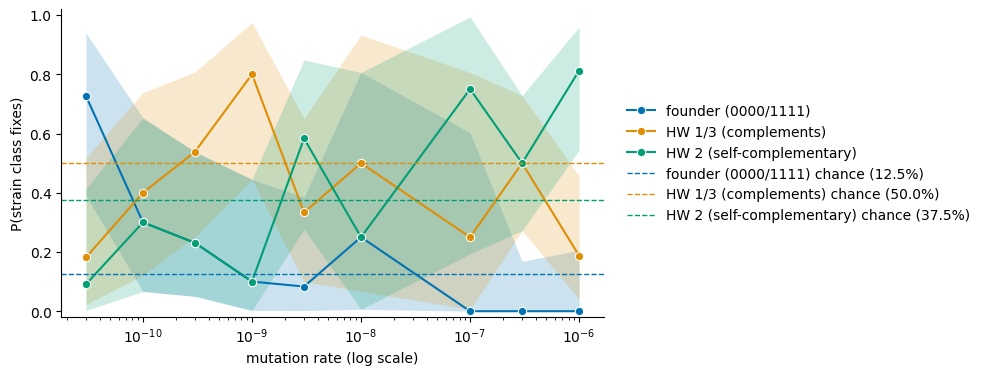

In [ ]:
_groups = [
    "founder (0000/1111)",
    "HW 1/3 (complements)",
    "HW 2 (self-complementary)",
]
_palette = dict(
    zip(_groups, sns.color_palette("colorblind", n_colors=len(_groups))),
)
# Genome-count fraction of the 16 possible 4-site genomes each group
# covers, under a uniform-over-genomes null: founder {0000, 1111}
# (2), HW 1/3 complements (2 * C(4,1) = 8), HW 2 self-complementary
# (C(4,2) = 6).
_chance = {
    "founder (0000/1111)": 2 / 16,
    "HW 1/3 (complements)": 8 / 16,
    "HW 2 (self-complementary)": 6 / 16,
}

with tp.teed(
    sns.lineplot,
    data=summary_df,
    x="mutation_rate",
    y="p",
    hue="group",
    hue_order=_groups,
    palette=_palette,
    marker="o",
    errorbar=None,
    teeplot_outattrs={"a": "founder-vs-hw13-vs-hw2-fixation-prob"},
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _ax:
    # Exact-CI band per group (fill_between, not bootstrap).
    for _group in _groups:
        _sub = summary_df[summary_df["group"] == _group].sort_values(
            "mutation_rate",
        )
        _ax.fill_between(
            _sub["mutation_rate"],
            _sub["ci_low"],
            _sub["ci_high"],
            color=_palette[_group],
            alpha=0.2,
            linewidth=0,
        )
    # Color-matched chance-expectation rule per group.
    for _group in _groups:
        _ax.axhline(
            _chance[_group],
            color=_palette[_group],
            linestyle="--",
            linewidth=1.0,
            label=f"{_group} chance ({_chance[_group]:.1%})",
        )
    _ax.set_xscale("log")
    _ax.set_ylim(-0.02, 1.02)
    _ax.set_xlabel("mutation rate (log scale)")
    _ax.set_ylabel("P(strain class fixes)")
    _ax.legend(
        title=None,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
    )
    sns.despine(ax=_ax)
    _ax.figure.set_size_inches(7, 4)

## Probability & 95% CI Table

Per-`mutation_rate` fixation probability with the exact
Clopper-Pearson 95% confidence interval, for both outcome groups.
`n_fixed` / `n_total` are the binomial counts behind each estimate.

In [ ]:
_table_df = (
    summary_df.assign(
        p=summary_df["p"].round(4),
        ci_low=summary_df["ci_low"].round(4),
        ci_high=summary_df["ci_high"].round(4),
        ci_95=summary_df.apply(
            lambda _r: f"[{_r['ci_low']:.3f}, {_r['ci_high']:.3f}]",
            axis=1,
        ),
    )[
        [
            "group",
            "mutation_rate",
            "n_fixed",
            "n_total",
            "p",
            "ci_low",
            "ci_high",
            "ci_95",
        ]
    ]
    .sort_values(["group", "mutation_rate"])
    .reset_index(drop=True)
)

print(_table_df.to_string(index=False))
mo.ui.table(_table_df, selection=None)

                    group  mutation_rate  n_fixed  n_total      p  ci_low  ci_high          ci_95
     HW 1/3 (complements)   3.000000e-11        2       11 0.1818  0.0228   0.5178 [0.023, 0.518]
     HW 1/3 (complements)   1.000000e-10        4       10 0.4000  0.1216   0.7376 [0.122, 0.738]
     HW 1/3 (complements)   3.000000e-10        7       13 0.5385  0.2513   0.8078 [0.251, 0.808]
     HW 1/3 (complements)   1.000000e-09        8       10 0.8000  0.4439   0.9748 [0.444, 0.975]
     HW 1/3 (complements)   3.000000e-09        4       12 0.3333  0.0992   0.6511 [0.099, 0.651]
     HW 1/3 (complements)   1.000000e-08        2        4 0.5000  0.0676   0.9324 [0.068, 0.932]
     HW 1/3 (complements)   1.000000e-07        1        4 0.2500  0.0063   0.8059 [0.006, 0.806]
     HW 1/3 (complements)   3.000000e-07       10       20 0.5000  0.2720   0.7280 [0.272, 0.728]
     HW 1/3 (complements)   1.000000e-06        3       16 0.1875  0.0405   0.4565 [0.040, 0.456]
HW 2 (self-complemen

,group,mutation_rate,n_fixed,n_total,p,ci_low,ci_high,ci_95
0,HW 1/3 (complements),3.000000e-11,2,11,0.1818,0.0228,0.5178,"[0.023, 0.518]"
1,HW 1/3 (complements),1.000000e-10,4,10,0.4000,0.1216,0.7376,"[0.122, 0.738]"
2,HW 1/3 (complements),3.000000e-10,7,13,0.5385,0.2513,0.8078,"[0.251, 0.808]"
3,HW 1/3 (complements),1.000000e-09,8,10,0.8000,0.4439,0.9748,"[0.444, 0.975]"
4,HW 1/3 (complements),3.000000e-09,4,12,0.3333,0.0992,0.6511,"[0.099, 0.651]"
...,...,...,...,...,...,...,...,...
22,founder (0000/1111),3.000000e-09,1,12,0.0833,0.0021,0.3848,"[0.002, 0.385]"
23,founder (0000/1111),1.000000e-08,1,4,0.2500,0.0063,0.8059,"[0.006, 0.806]"
24,founder (0000/1111),1.000000e-07,0,4,0.0000,0.0000,0.6024,"[0.000, 0.602]"
25,founder (0000/1111),3.000000e-07,0,20,0.0000,0.0000,0.1684,"[0.000, 0.168]"
